## 1. Import Libraries and Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from module_function import cross_validate_model,plot_all_modelsRegression_predictions

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('dataset/Housing_prediction_Cleaning.csv')
df_x = df.drop(columns='SalePrice')
df_y = df['SalePrice']

In [4]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 480 samples
Test set: 121 samples


## 2.Feature Scaling

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

In [7]:
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
}

df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=5, mode='regression')
df_hasil_perbandingan.sort_values(by='Mean R2-Score', ascending=False)

=== MENJALANKAN 5-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor

Proses CV Selesai!


,Model,Mean R2-Score,Mean MAE,Mean MSE,Mean RMSE
3,Gradient Boosting Regressor,0.875514,14817.231984,4.027833e+08,20069.462845
1,Ridge Regression,0.866592,15945.092765,4.325320e+08,20797.403847
0,Linear Regression,0.866390,15976.023370,4.331549e+08,20812.374767
2,Random Forest Regressor,0.863273,15253.503801,4.444594e+08,21082.205837


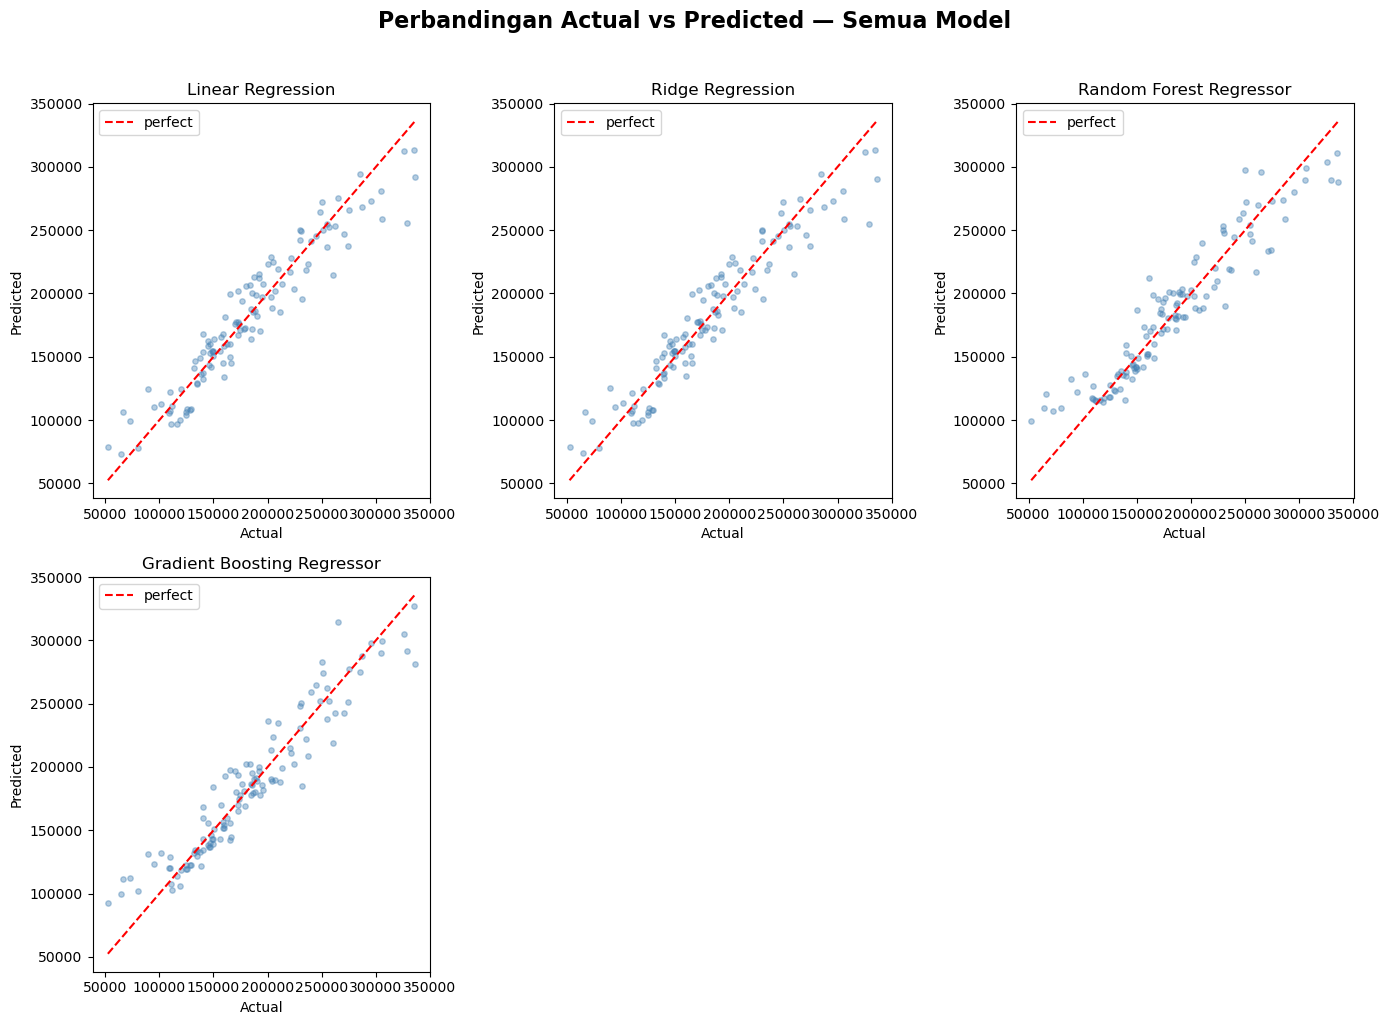

In [8]:
plot_all_modelsRegression_predictions(
    models_dict=regresi_pipelines,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)